In [66]:
#y_hat = model(x)
# regression model => BTCUSDT => future log return
#%pip install polars numpy torch altair python-binance

In [67]:
# Data and analysis libraries
import polars as pl                       # Fast dataframes for financial data
import numpy as np                        # Numerical computing library
from datetime import datetime, timedelta  # Date and time operations
import random

# Machine learning libraries
import torch                              # PyTorch framework
import torch.nn as nn                     # Neural network modules
import torch.optim as optim               # Optimization algorithms
import research                           # Model building and training utilities

# Visualization and
import altair as alt                      # Interactive visualization library

# data sources
import binance                            # Binance market data utilities
from binance.client import Client

In [68]:
research.set_seed(42)  # Set random seed for reproducibility

In [69]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [70]:
# time horizon of time series (time interval)
time_interval = '1h'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps 
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [71]:
sym = "BTCUSDT"
start_date = datetime(2024, 10, 29, 0, 0)
end_date = datetime(2025, 10, 9, 0, 0)
download_end = end_date + timedelta(days=1) - timedelta(seconds=1)

client = Client()
klines = client.get_historical_klines(
    symbol=sym,
    interval=Client.KLINE_INTERVAL_1HOUR,
    start_str=start_date.strftime("%d %b %Y %H:%M:%S"),
    end_str=download_end.strftime("%d %b %Y %H:%M:%S"),
)

In [72]:
time_interval = "1h"
kline_columns = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_volume",
    "trade_count",
    "taker_buy_volume",
    "taker_buy_quote_volume",
    "ignore",
]

ts = (
    pl.DataFrame(klines, schema=kline_columns, orient="row")
    .select(
        pl.col("open_time")
        .cast(pl.Datetime("ms"))
        .cast(pl.Datetime("us"))
        .alias("datetime"),
        pl.col("open").cast(pl.Float64),
        pl.col("high").cast(pl.Float64),
        pl.col("low").cast(pl.Float64),
        pl.col("close").cast(pl.Float64),
        pl.col("volume").cast(pl.Float64),
    )
    .sort("datetime")
)
ts

datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2024-10-29 00:00:00,69962.21,70010.0,69760.0,69960.88,654.60671
2024-10-29 01:00:00,69960.89,70387.97,69840.24,70310.58,1101.99256
2024-10-29 02:00:00,70310.58,71587.88,70221.11,71190.05,5855.97331
2024-10-29 03:00:00,71190.05,71430.96,70885.02,70938.14,1648.12275
2024-10-29 04:00:00,70938.15,71139.22,70926.73,71088.01,1128.1744
…,…,…,…,…,…
2025-10-09 19:00:00,120649.33,121108.12,120649.32,120951.72,714.9231
2025-10-09 20:00:00,120951.72,121199.97,120838.0,121109.09,743.67096
2025-10-09 21:00:00,121109.08,121512.7,121065.77,121461.02,436.22306


In [73]:
price_median = ts.select(
    "datetime",
    pl.col("close").alias("price_median"),
)
price_median

datetime,price_median
datetime[μs],f64
2024-10-29 00:00:00,69960.88
2024-10-29 01:00:00,70310.58
2024-10-29 02:00:00,71190.05
2024-10-29 03:00:00,70938.14
2024-10-29 04:00:00,71088.01
…,…
2025-10-09 19:00:00,120951.72
2025-10-09 20:00:00,121109.09
2025-10-09 21:00:00,121461.02


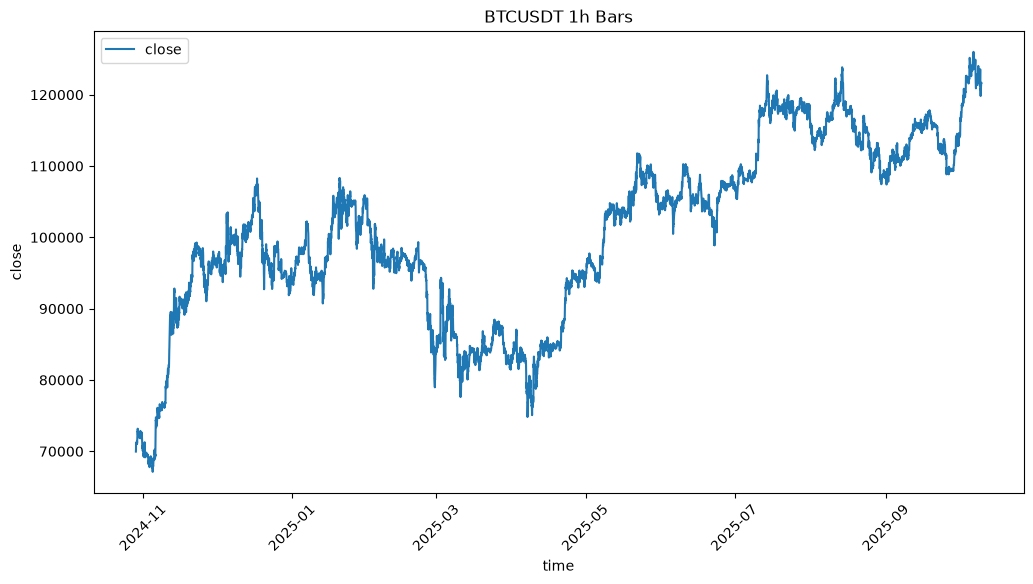

In [74]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [75]:
'''alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)'''

'alt.data_transformers.enable("vegafusion")\nresearch.plot_dyn_timeseries(ts, sym, \'close\', time_interval)'

### Feature Engineering

In [76]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [77]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create Target and Lagged Features

In [78]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,volume,close_log_return
datetime[μs],f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69962.21,70010.0,69760.0,69960.88,654.60671,null
2024-10-29 01:00:00,69960.89,70387.97,69840.24,70310.58,1101.99256,0.004986
2024-10-29 02:00:00,70310.58,71587.88,70221.11,71190.05,5855.97331,0.012431
2024-10-29 03:00:00,71190.05,71430.96,70885.02,70938.14,1648.12275,-0.003545
2024-10-29 04:00:00,70938.15,71139.22,70926.73,71088.01,1128.1744,0.00211
…,…,…,…,…,…,…
2025-10-09 19:00:00,120649.33,121108.12,120649.32,120951.72,714.9231,0.002503
2025-10-09 20:00:00,120951.72,121199.97,120838.0,121109.09,743.67096,0.0013
2025-10-09 21:00:00,121109.08,121512.7,121065.77,121461.02,436.22306,0.002902


In [79]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4')
)

ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69962.21,70010.0,69760.0,69960.88,654.60671,null,null,null,null,null
2024-10-29 01:00:00,69960.89,70387.97,69840.24,70310.58,1101.99256,0.004986,null,null,null,null
2024-10-29 02:00:00,70310.58,71587.88,70221.11,71190.05,5855.97331,0.012431,0.004986,null,null,null
2024-10-29 03:00:00,71190.05,71430.96,70885.02,70938.14,1648.12275,-0.003545,0.012431,0.004986,null,null
2024-10-29 04:00:00,70938.15,71139.22,70926.73,71088.01,1128.1744,0.00211,-0.003545,0.012431,0.004986,null
…,…,…,…,…,…,…,…,…,…,…
2025-10-09 19:00:00,120649.33,121108.12,120649.32,120951.72,714.9231,0.002503,-0.002687,0.009587,-0.011017,-0.001385
2025-10-09 20:00:00,120951.72,121199.97,120838.0,121109.09,743.67096,0.0013,0.002503,-0.002687,0.009587,-0.011017
2025-10-09 21:00:00,121109.08,121512.7,121065.77,121461.02,436.22306,0.002902,0.0013,0.002503,-0.002687,0.009587


In [80]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,69962.21,70010.0,69760.0,69960.88,654.60671,null,null,null,null,null
2024-10-29 01:00:00,69960.89,70387.97,69840.24,70310.58,1101.99256,0.004986,null,null,null,null
2024-10-29 02:00:00,70310.58,71587.88,70221.11,71190.05,5855.97331,0.012431,0.004986,null,null,null
2024-10-29 03:00:00,71190.05,71430.96,70885.02,70938.14,1648.12275,-0.003545,0.012431,0.004986,null,null
2024-10-29 04:00:00,70938.15,71139.22,70926.73,71088.01,1128.1744,0.00211,-0.003545,0.012431,0.004986,null
…,…,…,…,…,…,…,…,…,…,…
2025-10-09 19:00:00,120649.33,121108.12,120649.32,120951.72,714.9231,0.002503,-0.002687,0.009587,-0.011017,-0.001385
2025-10-09 20:00:00,120951.72,121199.97,120838.0,121109.09,743.67096,0.0013,0.002503,-0.002687,0.009587,-0.011017
2025-10-09 21:00:00,121109.08,121512.7,121065.77,121461.02,436.22306,0.002902,0.0013,0.002503,-0.002687,0.009587


In [81]:
ts = ts.drop_nulls()

### Train Model

In [82]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [83]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model,"Linear Model")
research.total_model_params(linear_model)



Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

#### y = w * x +b

### Split by time

In [84]:
features = ["close_log_return_lag_1"]
target = "close_log_return"
test_size = 0.25

In [85]:
len(ts)

8299

In [86]:
int(len(ts) * test_size)

2074

In [87]:
split_idz = int(len(ts) * (1 - test_size))
print(split_idz)

6224


In [88]:
ts_train , ts_test = ts[:split_idz], ts[split_idz:]

In [89]:
ts_train 

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 05:00:00,71088.0,71110.4,70886.59,71039.99,1131.77562,-0.000676,0.00211,-0.003545,0.012431,0.004986
2024-10-29 06:00:00,71039.99,71370.0,71006.0,71248.45,1502.7784,0.00293,-0.000676,0.00211,-0.003545,0.012431
2024-10-29 07:00:00,71248.46,71267.08,70837.83,71017.97,1627.98917,-0.00324,0.00293,-0.000676,0.00211,-0.003545
2024-10-29 08:00:00,71017.96,71219.72,70974.0,71134.01,881.19294,0.001633,-0.00324,0.00293,-0.000676,0.00211
2024-10-29 09:00:00,71134.0,71344.0,71114.68,71301.42,968.21912,0.002351,0.001633,-0.00324,0.00293,-0.000676
…,…,…,…,…,…,…,…,…,…,…
2025-07-15 08:00:00,116779.13,116862.02,116300.0,116777.47,1086.30795,-0.000014,-0.002492,-0.002257,-0.001238,0.00283
2025-07-15 09:00:00,116777.47,117224.08,116711.67,116779.99,920.92254,0.000022,-0.000014,-0.002492,-0.002257,-0.001238
2025-07-15 10:00:00,116780.0,117198.21,116744.48,117016.48,853.89059,0.002023,0.000022,-0.000014,-0.002492,-0.002257


In [90]:
ts_test

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-07-15 13:00:00,117204.18,118490.71,117157.25,118088.13,2210.06348,0.007514,0.00077,0.000833,0.002023,0.000022
2025-07-15 14:00:00,118088.13,118458.31,115736.92,116008.19,2687.57274,-0.01777,0.007514,0.00077,0.000833,0.002023
2025-07-15 15:00:00,116008.2,116750.0,115800.0,116391.43,2299.77308,0.003298,-0.01777,0.007514,0.00077,0.000833
2025-07-15 16:00:00,116391.43,117800.6,116362.97,117188.01,1624.68167,0.006821,0.003298,-0.01777,0.007514,0.00077
2025-07-15 17:00:00,117188.0,117538.46,117140.0,117372.99,995.72856,0.001577,0.006821,0.003298,-0.01777,0.007514
…,…,…,…,…,…,…,…,…,…,…
2025-10-09 19:00:00,120649.33,121108.12,120649.32,120951.72,714.9231,0.002503,-0.002687,0.009587,-0.011017,-0.001385
2025-10-09 20:00:00,120951.72,121199.97,120838.0,121109.09,743.67096,0.0013,0.002503,-0.002687,0.009587,-0.011017
2025-10-09 21:00:00,121109.08,121512.7,121065.77,121461.02,436.22306,0.002902,0.0013,0.002503,-0.002687,0.009587


In [91]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)

In [92]:
X_train

tensor([[ 2.1105e-03],
        [-6.7573e-04],
        [ 2.9301e-03],
        ...,
        [ 2.1579e-05],
        [ 2.0230e-03],
        [ 8.3287e-04]])

In [93]:
X_train.shape

torch.Size([6224, 1])

In [94]:
y_train

tensor([-0.0007,  0.0029, -0.0032,  ...,  0.0020,  0.0008,  0.0008])

In [95]:
y_train.shape

torch.Size([6224])

In [96]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[-0.0007],
        [ 0.0029],
        [-0.0032],
        ...,
        [ 0.0020],
        [ 0.0008],
        [ 0.0008]])

In [97]:
y_train.shape

torch.Size([6224, 1])

In [98]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[ 0.0075],
        [-0.0178],
        [ 0.0033],
        ...,
        [ 0.0029],
        [ 0.0019],
        [-0.0002]])

In [99]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 2.1105e-03],
         [-6.7573e-04],
         [ 2.9301e-03],
         ...,
         [ 2.1579e-05],
         [ 2.0230e-03],
         [ 8.3287e-04]]),
 tensor([[ 0.0008],
         [ 0.0075],
         [-0.0178],
         ...,
         [ 0.0013],
         [ 0.0029],
         [ 0.0019]]),
 tensor([[-0.0007],
         [ 0.0029],
         [-0.0032],
         ...,
         [ 0.0020],
         [ 0.0008],
         [ 0.0008]]),
 tensor([[ 0.0075],
         [-0.0178],
         [ 0.0033],
         ...,
         [ 0.0029],
         [ 0.0019],
         [-0.0002]]))

### Batch Gradient Descent

In [100]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# loss function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")
    


Training model...
Epoch [500/5000], Loss: 0.468828
Epoch [1000/5000], Loss: 0.234599
Epoch [1500/5000], Loss: 0.101732
Epoch [2000/5000], Loss: 0.036157
Epoch [2500/5000], Loss: 0.009766
Epoch [3000/5000], Loss: 0.001831
Epoch [3500/5000], Loss: 0.000232
Epoch [4000/5000], Loss: 0.000041
Epoch [4500/5000], Loss: 0.000029
Epoch [5000/5000], Loss: 0.000028

Learned parameters
linear.weight:
[[-0.05499003]]
linear.bias:
[0.00013373]

Test Loss: 0.000011, Train Loss: 0.000028


### Test Traiding Perdormance

In [101]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
0.000091,0.007514,true,1.0,0.007514,0.007514
-0.000279,-0.01777,true,-1.0,0.01777,0.025284
0.001111,0.003298,true,1.0,0.003298,0.028582
-0.000048,0.006821,false,-1.0,-0.006821,0.021762
-0.000241,0.001577,false,-1.0,-0.001577,0.020184
…,…,…,…,…,…
0.000282,0.002503,true,1.0,0.002503,0.011407
-0.000004,0.0013,false,-1.0,-0.0013,0.010107
0.000062,0.002902,true,1.0,0.002902,0.013009


In [102]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [103]:
trade_results = trade_results.with_columns(
    (pl.col("equity_curve") - pl.col("equity_curve").cum_max().alias("drawdown_log"))
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
0.000091,0.007514,true,1.0,0.007514,0.0
-0.000279,-0.01777,true,-1.0,0.01777,0.0
0.001111,0.003298,true,1.0,0.003298,0.0
-0.000048,0.006821,false,-1.0,-0.006821,-0.006821
-0.000241,0.001577,false,-1.0,-0.001577,-0.008398
…,…,…,…,…,…
0.000282,0.002503,true,1.0,0.002503,-0.094511
-0.000004,0.0013,false,-1.0,-0.0013,-0.095811
0.000062,0.002902,true,1.0,0.002902,-0.09291


In [104]:
trade_results = trade_results.with_columns(
    (
        pl.col("equity_curve")
        - pl.col("equity_curve").cum_max()
    ).alias("drawdown_log")
)

max_drawdown_log = trade_results["drawdown_log"].min()
max_drawdown_log

-0.13943997025489807

In [105]:
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.13015476177491558)

In [106]:
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-130.15476177491558)

In [107]:
win_rate = trade_results['is_won'].mean()
win_rate

0.5012048192771085

In [108]:
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev

5.282387035711539e-06

In [109]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return

0.010960958898067474

In [110]:
compound_return = np.exp(total_log_return)
compound_return

np.float64(1.0110212502905178)

In [111]:
1000*compound_return


np.float64(1011.0212502905179)

In [112]:
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.13943997025489807

In [113]:
equity_peak = trade_results['equity_curve'].max()
equity_peak

0.0

In [114]:
std = trade_results['trade_log_return'].std()
std

0.0033039068803191185

In [115]:
sharpe = ev / std * annualized_rate
sharpe

np.float64(0.14964233392329523)

In [116]:
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 2075,
 'win_rate': 0.5012048192771085,
 'avg_win': 0.002261900026657479,
 'avg_loss': -0.002262236787076983,
 'best_trade': 0.029096996411681175,
 'worst_trade': -0.02248360589146614,
 'ev': 5.282387035711539e-06,
 'std': 0.0033039068803191185,
 'total_log_return': 0.010960958898067474,
 'compound_return': np.float64(1.0110212502905178),
 'max_drawdown': -0.13943997025489807,
 'equity_trough': -0.033521804958581924,
 'equity_peak': 0.10591816902160645,
 'sharpe': np.float64(0.1496423339232869)}

In [117]:

target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 2075,
 'win_rate': 0.5185542168674698,
 'avg_win': 0.0022809295226453026,
 'avg_loss': -0.0022417526886707815,
 'best_trade': 0.029096996411681175,
 'worst_trade': -0.01932496577501297,
 'ev': 0.00010350324355866717,
 'std': 0.003302288707345724,
 'total_log_return': 0.21476921439170837,
 'compound_return': np.float64(1.2395757877001934),
 'max_drawdown': -0.18053337931632996,
 'equity_trough': -0.016294553875923157,
 'equity_peak': 0.2370191514492035,
 'sharpe': np.float64(2.933532969160648),
 'weights': '[-0.02665316]',
 'biases': '8.882991096470505e-05'}

In [118]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:    
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, test_size=test_size, no_epochs=200, loss=nn.L1Loss()))

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",2075,0.520482,0.002287,-0.002235,0.029097,-0.019325,0.000119,0.003302,0.246671,1.279759,-0.176809,-0.013555,0.258464,3.369815,"""[-0.02665021]""","""9.13475887500681e-05"""
"""close_log_return_lag_1""","""close_log_return""",2075,0.501205,0.00228,-0.002244,0.029097,-0.022484,0.000023,0.003304,0.047932,1.049099,-0.205645,0.007514,0.238855,0.654399,"""[-0.07532159]""","""0.00010251477942802012"""
"""close_log_return_lag_4""","""close_log_return""",2075,0.502651,0.002268,-0.002256,0.029097,-0.022484,0.000018,0.003304,0.037332,1.038038,-0.142409,-0.087273,0.072453,0.509681,"""[0.00148942]""","""8.173433161573485e-05"""
"""close_log_return_lag_3""","""close_log_return""",2075,0.501205,0.002255,-0.00227,0.029097,-0.022484,-0.000002,0.003304,-0.004176,0.995833,-0.257421,-0.228752,0.028669,-0.057013,"""[-0.02790912]""","""9.949911327566952e-05"""


In [119]:
research.auto_reg_corr_matrx(ts, target, max_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.021644,0.00422,-0.023672,0.006276
-0.021644,1.0,-0.021678,0.004349,-0.023618
0.00422,-0.021678,1.0,-0.021919,0.004249
-0.023672,0.004349,-0.021919,1.0,-0.021622
0.006276,-0.023618,0.004249,-0.021622,1.0


In [120]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

### Add Transaction Fees

In [121]:
maker_fee = 0.0001
taker_fee = 0.0003

roundtrip_fee_log = np.log(1-2 * taker_fee)

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col('trade_log_return') + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))

model_trades


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
0.000066,0.007514,true,1.0,0.007514,0.007514,0.0,-0.0006,0.006913,0.006913
0.000067,-0.01777,false,1.0,-0.01777,-0.010257,-0.01777,-0.0006,-0.018371,-0.011457
-0.00011,0.003298,false,-1.0,-0.003298,-0.013555,-0.021069,-0.0006,-0.003898,-0.015355
0.000556,0.006821,true,1.0,0.006821,-0.006734,-0.014248,-0.0006,0.00622,-0.009135
6.3225e-7,0.001577,true,1.0,0.001577,-0.005157,-0.012671,-0.0006,0.000977,-0.008158
…,…,…,…,…,…,…,…,…,…
-0.000165,0.002503,false,-1.0,-0.002503,0.218205,-0.028108,-0.0006,-0.003103,-1.024768
0.000158,0.0013,true,1.0,0.0013,0.219505,-0.026808,-0.0006,0.0007,-1.024068
0.000022,0.002902,true,1.0,0.002902,0.222407,-0.023907,-0.0006,0.002301,-1.021767


In [122]:
research.plot_column(model_trades, 'equity_curve_net')

alt.Chart(...)

In [123]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [124]:
model_trades['is_won'].mean()

0.5185542168674698

In [125]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
0.000066,0.007514,true,1.0,0.007514,0.007514,0.0,-0.0006,0.006913,0.006913,0.007414,0.007214,0.007414,0.007214
0.000067,-0.01777,false,1.0,-0.01777,-0.010257,-0.01777,-0.0006,-0.018371,-0.011457,-0.01787,-0.01807,-0.010457,-0.010857
-0.00011,0.003298,false,-1.0,-0.003298,-0.013555,-0.021069,-0.0006,-0.003898,-0.015355,-0.003398,-0.003598,-0.013855,-0.014455
0.000556,0.006821,true,1.0,0.006821,-0.006734,-0.014248,-0.0006,0.00622,-0.009135,0.006721,0.006521,-0.007134,-0.007934
6.3225e-7,0.001577,true,1.0,0.001577,-0.005157,-0.012671,-0.0006,0.000977,-0.008158,0.001477,0.001277,-0.005657,-0.006657
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.000165,0.002503,false,-1.0,-0.002503,0.218205,-0.028108,-0.0006,-0.003103,-1.024768,-0.002603,-0.002803,0.011094,-0.403189
0.000158,0.0013,true,1.0,0.0013,0.219505,-0.026808,-0.0006,0.0007,-1.024068,0.0012,0.001,0.012295,-0.402188
0.000022,0.002902,true,1.0,0.002902,0.222407,-0.023907,-0.0006,0.002301,-1.021767,0.002802,0.002602,0.015096,-0.399587


In [126]:
time_interval = "12h"
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

ts = (
    ts.sort("datetime")
    .group_by_dynamic(
        "datetime",
        every=time_interval,
        offset="0m",
    )
    .agg(
        [
            pl.col("open").first().alias("open"),
            pl.col("high").max().alias("high"),
            pl.col("low").min().alias("low"),
            pl.col("close").last().alias("close"),
            pl.col("volume").sum().alias("volume"),
        ]
    )
    .sort("datetime")
)
ts

datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2024-10-29 00:00:00,71088.0,71578.95,70837.83,71452.01,8596.36696
2024-10-29 12:00:00,71452.02,73620.12,70929.0,72736.42,31143.36925
2024-10-30 00:00:00,72736.41,72785.72,71926.82,71983.99,9868.85743
2024-10-30 12:00:00,71984.0,72961.0,71436.0,72344.74,17017.13313
2024-10-31 00:00:00,72344.75,72700.0,72030.08,72226.0,8385.60352
…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986


In [127]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,71088.0,71578.95,70837.83,71452.01,8596.36696,null,null,null,null
2024-10-29 12:00:00,71452.02,73620.12,70929.0,72736.42,31143.36925,0.017816,null,null,null
2024-10-30 00:00:00,72736.41,72785.72,71926.82,71983.99,9868.85743,-0.010398,0.017816,null,null
2024-10-30 12:00:00,71984.0,72961.0,71436.0,72344.74,17017.13313,0.004999,-0.010398,0.017816,null
2024-10-31 00:00:00,72344.75,72700.0,72030.08,72226.0,8385.60352,-0.001643,0.004999,-0.010398,0.017816
…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647


In [128]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",172,0.55814,0.007464,-0.007495,0.040275,-0.025393,0.000854,0.010117,0.146907,1.158246,-0.071505,-0.048663,0.17809,2.281089,"""[-0.11142983]""","""0.0010574446059763432"""
"""close_log_return_lag_3""","""close_log_return""",172,0.5,0.00761,-0.007345,0.040275,-0.025393,0.000132,0.010152,0.02277,1.023032,-0.084681,-0.081616,0.037858,0.352336,"""[0.08271194]""","""0.0008608960197307169"""
"""close_log_return_lag_2""","""close_log_return""",172,0.476744,0.007651,-0.007319,0.040275,-0.025393,-0.000182,0.010151,-0.031293,0.969191,-0.113163,-0.043246,0.069917,-0.484252,"""[-0.09445773]""","""0.0010399912716820836"""


In [129]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.104201,-0.086806,0.075541
-0.104201,1.0,-0.104688,-0.086275
-0.086806,-0.104688,1.0,-0.105465
0.075541,-0.086275,-0.105465,1.0


In [130]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",172,0.55814,0.007464,-0.007495,0.040275,-0.025393,0.000854,0.010117,0.146907,1.158246,-0.071505,-0.048663,0.17809,2.281089,"""[-0.11100754]""","""0.0010510708671063185"""
"""close_log_return_lag_3""","""close_log_return""",172,0.5,0.00761,-0.007345,0.040275,-0.025393,0.000132,0.010152,0.02277,1.023032,-0.084681,-0.081616,0.037858,0.352336,"""[0.08292912]""","""0.0008589532226324081"""
"""close_log_return_lag_2""","""close_log_return""",172,0.476744,0.007651,-0.007319,0.040275,-0.025393,-0.000182,0.010151,-0.031293,0.969191,-0.113163,-0.043246,0.069917,-0.484252,"""[-0.09423628]""","""0.0010365701746195555"""


In [131]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss(), test_size=0.3)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",207,0.516908,0.007919,-0.007224,0.043966,-0.025393,0.000604,0.010438,0.124938,1.133078,-0.130263,-0.015886,0.149266,1.562346,"""[0.02397635]""","""0.0007317642448469996"""
"""close_log_return_lag_1""","""close_log_return""",207,0.531401,0.007521,-0.007654,0.043966,-0.025393,0.00041,0.010447,0.08491,1.088619,-0.078893,-0.030898,0.119657,1.060846,"""[-0.118816]""","""0.0006432874361053109"""
"""close_log_return_lag_2""","""close_log_return""",207,0.507246,0.007812,-0.007348,0.040275,-0.043966,0.000342,0.01045,0.07075,1.073313,-0.10135,-0.015886,0.110354,0.883718,"""[-0.04895137]""","""0.0008567240438424051"""


In [132]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [133]:
research.plot_column(model_trades, 'equity_curve_net_taker')

alt.Chart(...)

In [134]:
time_interval = '12h'

In [135]:
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-29 00:00:00,71088.0,71578.95,70837.83,71452.01,8596.36696,null,null,null,null,null
2024-10-29 12:00:00,71452.02,73620.12,70929.0,72736.42,31143.36925,0.017816,null,null,null,null
2024-10-30 00:00:00,72736.41,72785.72,71926.82,71983.99,9868.85743,-0.010398,0.017816,null,null,null
2024-10-30 12:00:00,71984.0,72961.0,71436.0,72344.74,17017.13313,0.004999,-0.010398,0.017816,null,null
2024-10-31 00:00:00,72344.75,72700.0,72030.08,72226.0,8385.60352,-0.001643,0.004999,-0.010398,0.017816,null
…,…,…,…,…,…,…,…,…,…,…
2025-10-07 12:00:00,124453.37,125126.0,120574.94,121332.95,14960.42401,-0.025393,-0.001647,0.003564,0.005916,0.000143
2025-10-08 00:00:00,121332.96,123200.0,121066.14,122884.14,8486.36814,0.012704,-0.025393,-0.001647,0.003564,0.005916
2025-10-08 12:00:00,122884.14,124197.25,121649.68,123306.0,8526.24986,0.003427,0.012704,-0.025393,-0.001647,0.003564


In [136]:
# research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())
benchmark_12h_mse = research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    max_no_features=3,
    loss=nn.MSELoss(),
).with_columns(pl.lit("MSE").alias("loss"))
benchmark_12h_mse

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases,loss
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""close_log_return_lag_1,close_log_return_lag_3,close_log_return_lag_4""","""close_log_return""",172,0.534884,0.007859,-0.007038,0.040275,-0.025393,0.00093,0.01011,0.159985,1.173493,-0.083183,-0.028225,0.181926,2.485815,"""[-0.10884043 0.08034429 0.05110904]""","""0.0009194859303534031""","""MSE"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_4""","""close_log_return""",172,0.563953,0.007391,-0.007589,0.040275,-0.025393,0.000859,0.010116,0.147755,1.159229,-0.066963,-0.027039,0.162842,2.294353,"""[-0.1265214 -0.10298567 0.03504728]""","""0.0011372945737093687""","""MSE"""
"""close_log_return_lag_1""","""close_log_return""",172,0.55814,0.007464,-0.007495,0.040275,-0.025393,0.000854,0.010117,0.146907,1.158246,-0.071505,-0.048663,0.17809,2.281089,"""[-0.11096171]""","""0.0010552122257649899""","""MSE"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",172,0.511628,0.008042,-0.006886,0.040275,-0.025393,0.000752,0.010125,0.129326,1.138061,-0.087571,-0.07813,0.151268,2.006488,"""[-0.11368671 0.08413722]""","""0.0009697912028059363""","""MSE"""
"""close_log_return_lag_1,close_log_return_lag_4""","""close_log_return""",172,0.540698,0.007591,-0.007343,0.040275,-0.025393,0.000732,0.010126,0.125867,1.134131,-0.07641,-0.042525,0.157049,1.952528,"""[-0.11255039 0.04012392]""","""0.0010140836238861084""","""MSE"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""close_log_return_lag_4""","""close_log_return""",172,0.517442,0.007409,-0.007551,0.040275,-0.025393,0.00019,0.010151,0.032618,1.033155,-0.130263,-0.084223,0.056946,0.50475,"""[0.03176169]""","""0.0009182067587971687""","""MSE"""
"""close_log_return_lag_3""","""close_log_return""",172,0.5,0.00761,-0.007345,0.040275,-0.025393,0.000132,0.010152,0.02277,1.023032,-0.084681,-0.081616,0.037858,0.352336,"""[0.08289561]""","""0.0008707888191565871""","""MSE"""
"""close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4""","""close_log_return""",172,0.476744,0.007812,-0.007172,0.040275,-0.025393,-0.000028,0.010153,-0.004887,0.995125,-0.106867,-0.06794,0.038927,-0.075611,"""[-0.08451486 0.07958972 0.03283162]""","""0.0009213738376274705""","""MSE"""


In [137]:
# research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())
benchmark_12h_huber = research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    max_no_features=3,
    loss=nn.HuberLoss(),
).with_columns(pl.lit("Huber").alias("loss"))
benchmark_12h_huber

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases,loss
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""close_log_return_lag_1,close_log_return_lag_4""","""close_log_return""",172,0.540698,0.00779,-0.007109,0.040275,-0.025393,0.000947,0.010108,0.162889,1.176906,-0.07641,-0.042525,0.194071,2.531324,"""[-0.11245167 0.03878172]""","""0.0010219807736575603""","""Huber"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",172,0.540698,0.007783,-0.007118,0.040275,-0.025393,0.000939,0.010109,0.161524,1.1753,-0.090465,-0.026878,0.18338,2.509928,"""[-0.1185589 -0.09876697 0.05974434]""","""0.0010968530550599098""","""Huber"""
"""close_log_return_lag_1,close_log_return_lag_3,close_log_return_lag_4""","""close_log_return""",172,0.534884,0.007859,-0.007038,0.040275,-0.025393,0.00093,0.01011,0.159985,1.173493,-0.083183,-0.028225,0.181926,2.485815,"""[-0.10967786 0.0820192 0.05257222]""","""0.0009178526815958321""","""Huber"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_4""","""close_log_return""",172,0.563953,0.007391,-0.007589,0.040275,-0.025393,0.000859,0.010116,0.147755,1.159229,-0.066963,-0.027039,0.162842,2.294353,"""[-0.12665182 -0.10294331 0.03496042]""","""0.001133337733335793""","""Huber"""
"""close_log_return_lag_1""","""close_log_return""",172,0.55814,0.007464,-0.007495,0.040275,-0.025393,0.000854,0.010117,0.146907,1.158246,-0.071505,-0.048663,0.17809,2.281089,"""[-0.11129476]""","""0.0010606213472783566""","""Huber"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""close_log_return_lag_3""","""close_log_return""",172,0.505814,0.007526,-0.007427,0.040275,-0.025393,0.000136,0.010152,0.023423,1.0237,-0.084681,-0.080963,0.03851,0.362437,"""[0.08222972]""","""0.0008770967833697796""","""Huber"""
"""close_log_return_lag_2,close_log_return_lag_4""","""close_log_return""",172,0.494186,0.007651,-0.007307,0.040275,-0.025393,0.000085,0.010152,0.014627,1.014734,-0.093834,0.002143,0.096508,0.226312,"""[-0.09410229 0.0239993 ]""","""0.001017123693600297""","""Huber"""
"""close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4""","""close_log_return""",172,0.476744,0.007812,-0.007172,0.040275,-0.025393,-0.000028,0.010153,-0.004887,0.995125,-0.106867,-0.06794,0.038927,-0.075611,"""[-0.08485814 0.07932075 0.03165691]""","""0.0009211049182340503""","""Huber"""


In [138]:
# research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)
benchmark_12h_l1 = research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    max_no_features=3,
    loss=nn.L1Loss(),
    test_size=0.25,
).with_columns(pl.lit("L1").alias("loss"))
benchmark_12h_l1

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases,loss
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",172,0.569767,0.007607,-0.007306,0.040275,-0.025393,0.001191,0.010082,0.204872,1.227368,-0.06171,-0.038109,0.226813,3.191962,"""[-0.10649737 0.02265945]""","""0.0007132937898859382""","""L1"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_4""","""close_log_return""",172,0.546512,0.007552,-0.007387,0.040275,-0.025393,0.000778,0.010123,0.133747,1.143103,-0.076496,-0.026015,0.164929,2.075472,"""[-0.118487 -0.02639762 -0.01461693]""","""0.0007736416300758719""","""L1"""
"""close_log_return_lag_1,close_log_return_lag_3,close_log_return_lag_4""","""close_log_return""",172,0.534884,0.007519,-0.007429,0.040275,-0.025393,0.000566,0.010137,0.097434,1.102338,-0.076496,-0.038109,0.128616,1.509868,"""[-0.11358366 0.00733865 -0.00950307]""","""0.0006634697783738375""","""L1"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",172,0.511628,0.00781,-0.007129,0.040275,-0.025393,0.000514,0.01014,0.088464,1.092494,-0.08276,-0.021625,0.103551,1.370485,"""[-0.04656984 0.02453727]""","""0.0007931545260362327""","""L1"""
"""close_log_return_lag_1""","""close_log_return""",172,0.534884,0.007467,-0.007489,0.040275,-0.025393,0.000511,0.01014,0.08783,1.091803,-0.07641,-0.021012,0.122577,1.360648,"""[-0.11810306]""","""0.000678685144521296""","""L1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""close_log_return_lag_3""","""close_log_return""",172,0.517442,0.007409,-0.007551,0.040275,-0.025393,0.00019,0.010151,0.032618,1.033155,-0.130263,-0.084223,0.056946,0.50475,"""[0.03122921]""","""0.000840790627989918""","""L1"""
"""close_log_return_lag_4""","""close_log_return""",172,0.517442,0.007409,-0.007551,0.040275,-0.025393,0.00019,0.010151,0.032618,1.033155,-0.130263,-0.084223,0.056946,0.50475,"""[0.00396493]""","""0.0006835072999820113""","""L1"""
"""close_log_return_lag_3,close_log_return_lag_4""","""close_log_return""",172,0.517442,0.007409,-0.007551,0.040275,-0.025393,0.00019,0.010151,0.032618,1.033155,-0.130263,-0.084223,0.056946,0.50475,"""[ 0.02544174 -0.00465387]""","""0.0008857668726705015""","""L1"""


In [139]:
features_12h = [f'{target}_lag_{i}' for i in range(1, 4)]
benchmark_12h = pl.concat([
    benchmark_12h_mse,
    benchmark_12h_huber,
    benchmark_12h_l1,
])
benchmark_12h_three_features = (
    benchmark_12h
    .filter(pl.col('features') == ','.join(features_12h))
    .sort('sharpe', descending=True)
)
best_12h_row = benchmark_12h_three_features.row(0, named=True)
best_12h_loss_name = best_12h_row['loss']
best_12h_loss = {
    'MSE': nn.MSELoss(),
    'Huber': nn.HuberLoss(),
    'L1': nn.L1Loss(),
}[best_12h_loss_name]

print(
    f"Best 12h model: features={features_12h}, "
    f"loss={best_12h_loss_name}, sharpe={best_12h_row['sharpe']:.6f}"
)
benchmark_12h_three_features

Best 12h model: features=['close_log_return_lag_1', 'close_log_return_lag_2', 'close_log_return_lag_3'], loss=Huber, sharpe=2.509928


features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases,loss
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",172,0.540698,0.007783,-0.007118,0.040275,-0.025393,0.000939,0.010109,0.161524,1.1753,-0.090465,-0.026878,0.18338,2.509928,"""[-0.1185589 -0.09876697 0.05974434]""","""0.0010968530550599098""","""Huber"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",172,0.534884,0.007645,-0.007285,0.040275,-0.025393,0.000701,0.010128,0.120539,1.128105,-0.105605,-0.042019,0.142395,1.869471,"""[-0.11627443 -0.10044239 0.06085176]""","""0.001096776919439435""","""MSE"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",172,0.52907,0.007486,-0.007468,0.040275,-0.025393,0.000444,0.010143,0.076336,1.079325,-0.108675,-0.058463,0.120199,1.182214,"""[-0.08590242 -0.06918827 0.01624985]""","""0.0007259367266669869""","""L1"""


In [140]:
# features = ['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']
# model = LinearModel(len(features))
# model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
# model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
# research.plot_column(model_trades, 'equity_curve')
features = features_12h
model = LinearModel(len(features))
model.apply(research.init_weights)
model_trades = research.learn_model_trades(
    ts.drop_nulls(),
    features,
    target,
    model,
    no_epochs=200,
    loss=best_12h_loss,
)
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [141]:
torch.save(model.state_dict(), 'model_weights.pth')
print(f"Saved model_weights.pth: 12h, features={features}, loss={best_12h_loss_name}")

Saved model_weights.pth: 12h, features=['close_log_return_lag_1', 'close_log_return_lag_2', 'close_log_return_lag_3'], loss=Huber
